In [1]:
import os
import sys
from copy import deepcopy
from pathlib import Path

import einops
import matplotlib.pyplot as plt
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import pykoopman as pk
import scipy
import seaborn as sns
import torch
from jaxtyping import Float, Int
from matrepr import mdisplay, mprint
from pydmd import DMD
from rich import print as rprint
from torch import Tensor, nn, optim
from torch.nn.functional import mse_loss
from torch.optim import LBFGS, Adam

from analysis.koopman import KoopmanWrapper
from nnscaling import aesthetics
from nnscaling.data import (
    DatasetConfig,
    get_dataset_class,
)
from nnscaling.models import MLP, ScaledModel
from nnscaling.trajectory import TrajectoryEngine, reshape_append_time
from nnscaling.utils import compute_model_accuracy
from nnscaling.visualization import plot_decision_boundary, plot_eigenvalues

%load_ext autoreload
%autoreload 2

In [2]:
NUM_TRAJ = 1_500  # Try to keep below 3_000
BATCH_SIZE = 5_000  # Number of Koopman inferences to run at once
DELAY_PARAM = 10  # Typically set to iterations - 2

In [3]:
# Project directory
project_dir = Path(os.getcwd()).parent

# Load original model
file_path = Path(project_dir, "model_saves/yinyang_model.safetensors")
original_model = MLP.load_model(file_path).eval()

# Load scaled model
file_path = Path(project_dir, "model_saves/scaling/loc_1_scaled_yinyang_model.safetensors")
scaled_model = ScaledModel.load_model(original_model, file_path).eval()

# Dataset config
dataset_config = DatasetConfig(
    dataset_name="YinYangNoDotsBinaryDataset",
    num_samples=3_000,
    split="train",
    seed=42,
)
DatasetClass = get_dataset_class(name=dataset_config.dataset_name)
dataset = DatasetClass(config=dataset_config)

In [4]:
# Generate trajectories
trajectory_engine = TrajectoryEngine(
    dataset_config=dataset_config,
    scaled_model=scaled_model,
)
acts_dict = trajectory_engine.generate_trajectory(
    num_train=NUM_TRAJ,
    magic_number=-0.5,
    seed=0,
)

In [5]:
# Train states
train_states = acts_dict["scaled_train"]
test_states = acts_dict["scaled_test"]

rprint(
    f"Trajectory tensor: {train_states.shape}",
    "\n\[batch, state, iteration]",
)

train_states = reshape_append_time(acts_dict["scaled_train"])
rprint(
    f"Trajectory tensor: {train_states.shape}",
    "\n\[state, batch * iteration]",
)

Trajectory tensor: torch.Size([1500, 10, 12]) 
[batch, state, iteration]

Trajectory tensor: torch.Size([10, 18000]) 
[state, batch * iteration]

In [6]:
observable_fn = pk.observables.TimeDelay(delay=1, n_delays=DELAY_PARAM)
regressor = pk.regression.EDMD(svd_rank=110)
# regressor = DMD()

dmd_model = pk.Koopman(observables=observable_fn, regressor=regressor)
dmd_model.fit(train_states.numpy().T)

Koopman(observables=TimeDelay(n_delays=10), regressor=EDMD(svd_rank=110))

In [7]:
koopman_scaled_model = KoopmanWrapper(scaled_model, dmd_model=dmd_model, n_delays=DELAY_PARAM)

torch.Size([110, 110])

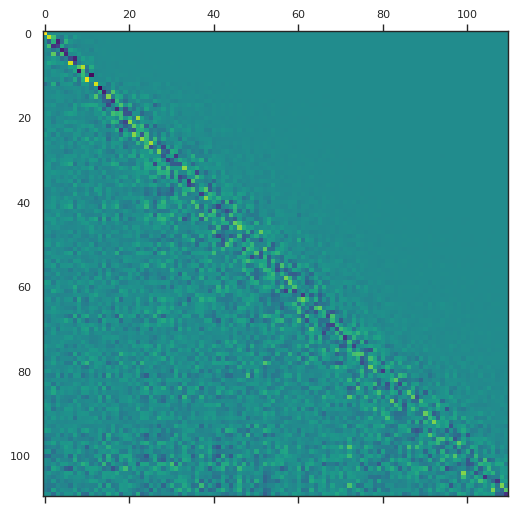

In [8]:
plt.matshow(koopman_scaled_model.tensor_A.T, cmap="viridis", norm="linear")
rprint(koopman_scaled_model.tensor_A.T.shape)

/home/nsa325/work/nnscaling/analysis/koopman.py:69: UserWarning: The `forward` method calls the `forward_koopman` method.
  warnings.warn("The `forward` method calls the `forward_koopman` method.")
/home/nsa325/work/nnscaling/analysis/koopman.py:69: UserWarning: The `forward` method calls the `forward_koopman` method.
  warnings.warn("The `forward` method calls the `forward_koopman` method.")


Testing Accuracy: 0.925000011920929


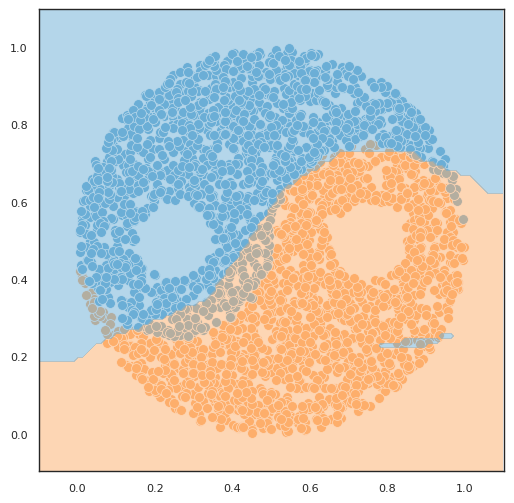

In [9]:
print(f"Testing Accuracy: {compute_model_accuracy(koopman_scaled_model.to('cpu'), dataset)}")

plot_decision_boundary(
    koopman_scaled_model,
    koopman_scaled_model.state_dict(),
    dataset.features,
    dataset.labels.squeeze(),
    labels=[0, 1],
)

In [10]:
###############
# FOR PROTOTYPE
tensor_A = torch.from_numpy(deepcopy(dmd_model.A)).float()
tensor_lamda = torch.from_numpy(deepcopy(dmd_model.lamda))
frozen_lamda = torch.from_numpy(deepcopy(dmd_model.lamda))
tensor_V = torch.from_numpy(deepcopy(dmd_model._regressor_eigenvectors))
tensor_V_inv = torch.linalg.inv(tensor_V)
tensor_B = torch.eye(tensor_A.shape[0])
tensor_C = torch.from_numpy(dmd_model.C).float()

tensor_mm = torch.from_numpy(dmd_model.observables.measurement_matrix_).float()
tensor_ur = torch.from_numpy(dmd_model.regressor.ur).float()
###############


(<Figure size 400x400 with 1 Axes>, <Axes: title={'center': 'h=10, r=1500'}>)

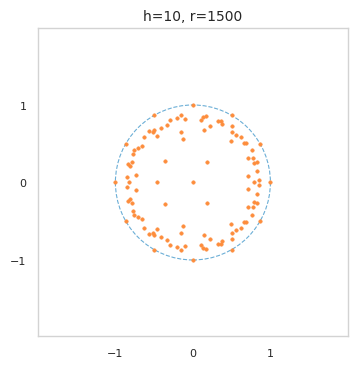

In [11]:
koop_eigenvals = np.diag(tensor_lamda)
filtered_eigenvals = koop_eigenvals[np.abs(koop_eigenvals) > 0.8]
plot_eigenvalues(
    eigenvalues_dict={(NUM_TRAJ, DELAY_PARAM): koop_eigenvals},
    num_trajectories_list=[NUM_TRAJ],
    num_delays_list=[DELAY_PARAM],
    tile_size=4,
)

In [12]:
def simulate_lamda(x0, n_steps):
    if isinstance(x0, torch.Tensor):
        x0 = x0.numpy()

    # NOTE: Time-delay embedding (TDE) on the batched input tensor
    # returns tensor `Hx` with shape [batch iteration feature],
    # where feature is a spatio-temporal dimension.
    # PyKooopman's time delay observable is NOT batched; it returns [feature iteration].
    x0 = x0[:, :, : DELAY_PARAM + 1]
    tensor_obs = koopman_scaled_model._tde(x0).float()

    # NOTE: The original implementation computes U.T @ Hx.
    # However, because X is batched, we compute (U.T @ H.x).T = H.x.T @ U
    # taking a page from the F.linear book. This keeps the batch dimension intact
    y = tensor_obs @ tensor_ur

    # Flatten to [batch, RSV]
    # y = tensor_ur.T.flatten(start_dim=0, end_dim=1).T
    y = y.flatten(start_dim=1).to(torch.complex64)
    y = y @ tensor_V_inv.conj().T

    y_steps = []
    # Step forward and return to original space
    # NOTE: We use the transpose matmult to preserve batch
    for _ in range(n_steps):
        y = y @ tensor_lamda.conj()
        y_steps.append(y)

    y = torch.stack(y_steps, dim=0) @ tensor_V.conj().T

    # Return back from observable space
    y = y.float() @ tensor_C.T

    # Rearrange for standard order
    y = einops.rearrange(y, "iteration batch state -> batch state iteration")

    return y

In [13]:
def simulate_A(x0, n_steps):
    if isinstance(x0, torch.Tensor):
        x0 = x0.numpy()

    # NOTE: Time-delay embedding (TDE) on the batched input tensor
    # returns tensor `Hx` with shape [batch iteration feature],
    # where feature is a spatio-temporal dimension.
    # PyKooopman's time delay observable is NOT batched; it returns [feature iteration].
    x0 = x0[:, :, : DELAY_PARAM + 1]
    tensor_obs = koopman_scaled_model._tde(x0).float()

    # NOTE: The original implementation computes U.T @ Hx.
    # However, because X is batched, we compute (U.T @ H.x).T = H.x.T @ U
    # taking a page from the F.linear book. This keeps the batch dimension intact
    y = tensor_obs @ tensor_ur

    # Flatten to [batch, RSV]
    # y = tensor_ur.T.flatten(start_dim=0, end_dim=1).T
    y = y.flatten(start_dim=1)

    y_steps = []
    # Step forward and return to original space
    # NOTE: We use the transpose matmult to preserve batch
    for _ in range(n_steps):
        y = y @ tensor_A.T
        y_steps.append(y)

    # Return back from observable space
    y = torch.stack(y_steps, dim=0) @ tensor_C.T

    # Rearrange for standard order
    y = einops.rearrange(y, "iteration batch state -> batch state iteration")

    return y

In [14]:
tensor_lamda.requires_grad = True

# Define the optimizer for both real and imaginary parts
optimizer = optim.Adam([tensor_lamda], lr=1e-3, betas=(0.9, 0.999))  # Use a small learning rate

num_epochs = 15_000
alpha = 100
for epoch in range(num_epochs):
    optimizer.zero_grad()  # Zero the gradients from the previous step

    # Use tensor_lamda in your simulation function
    Xkoop = simulate_lamda(x0=acts_dict["scaled_train"], n_steps=12 - DELAY_PARAM - 1)
    main_loss = mse_loss(acts_dict["scaled_train"][:, :, -1], Xkoop[:, :, -1], reduction="sum")

    # # Eigenvalue magnitude constraint
    # real_part = tensor_lamda.diag().real
    # imag_part = tensor_lamda.diag().imag
    # magnitude = torch.sqrt(real_part**2 + imag_part**2)
    # magnitude_loss = ((magnitude - 1) ** 2).sum()  # Penalize deviations from unit magnitude

    deviation = tensor_lamda - torch.zeros_like(tensor_lamda)
    l1_loss = deviation.abs().sum()  # L1 regularization for sparsity
    l2_loss = (deviation.abs() ** 2).sum()

    # Total loss
    total_loss = main_loss + alpha * l1_loss + 0.001 * l2_loss

    # Backpropagation
    total_loss.backward()

    if tensor_lamda.grad.is_conj():
        tensor_lamda.grad = tensor_lamda.grad.resolve_conj()

    # Update the parameters
    optimizer.step()

    # Zero out the off-diagonal elements
    with torch.no_grad():
        tensor_lamda.data = torch.diag(tensor_lamda.diag())

    # Optionally, print the loss every 500 epochs to monitor progress
    if (epoch + 1) % 500 == 0:
        print(f"Epoch [{epoch + 1}/{num_epochs}], Loss: {total_loss.item():.6f}")


/tmpdata/ipykernel_846242/2428475086.py:32: UserWarning: Casting complex values to real discards the imaginary part (Triggered internally at ../aten/src/ATen/native/Copy.cpp:299.)
  y = y.float() @ tensor_C.T


Epoch [500/15000], Loss: 3374.739014
Epoch [1000/15000], Loss: 1247.477539
Epoch [1500/15000], Loss: 1235.647705
Epoch [2000/15000], Loss: 1235.657227
Epoch [2500/15000], Loss: 1235.707397


KeyboardInterrupt: 

(<Figure size 400x400 with 1 Axes>, <Axes: title={'center': 'h=10, r=1500'}>)

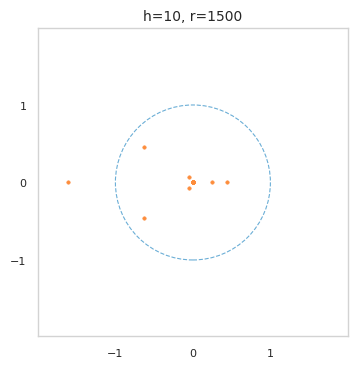

In [15]:
koop_eigenvals = np.diag(tensor_lamda.detach())
filtered_eigenvals = koop_eigenvals[np.abs(koop_eigenvals) > 0.8]
plot_eigenvalues(
    eigenvalues_dict={(NUM_TRAJ, DELAY_PARAM): koop_eigenvals},
    num_trajectories_list=[NUM_TRAJ],
    num_delays_list=[DELAY_PARAM],
    tile_size=4,
)

In [16]:
koopman_scaled_model.simulate = simulate_lamda

/home/nsa325/work/nnscaling/analysis/koopman.py:69: UserWarning: The `forward` method calls the `forward_koopman` method.
  warnings.warn("The `forward` method calls the `forward_koopman` method.")
/home/nsa325/work/nnscaling/analysis/koopman.py:69: UserWarning: The `forward` method calls the `forward_koopman` method.
  warnings.warn("The `forward` method calls the `forward_koopman` method.")


Testing Accuracy: 0.5196666717529297


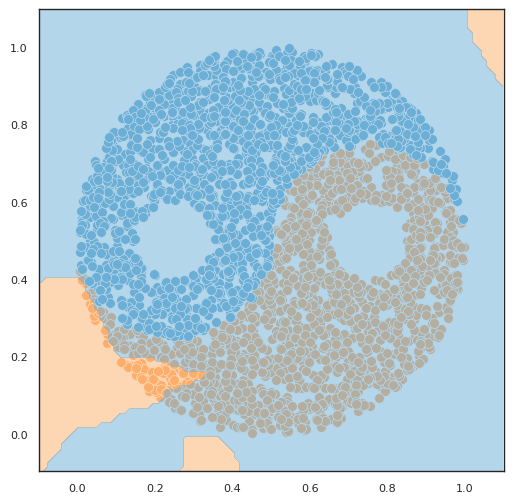

In [17]:
print(f"Testing Accuracy: {compute_model_accuracy(koopman_scaled_model.to('cpu'), dataset)}")

plot_decision_boundary(
    koopman_scaled_model,
    koopman_scaled_model.state_dict(),
    dataset.features,
    dataset.labels.squeeze(),
    labels=[0, 1],
)

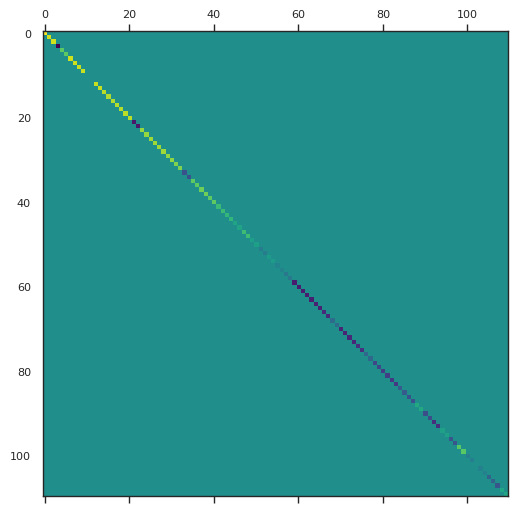

In [18]:
plt.matshow(frozen_lamda.real, cmap="viridis")

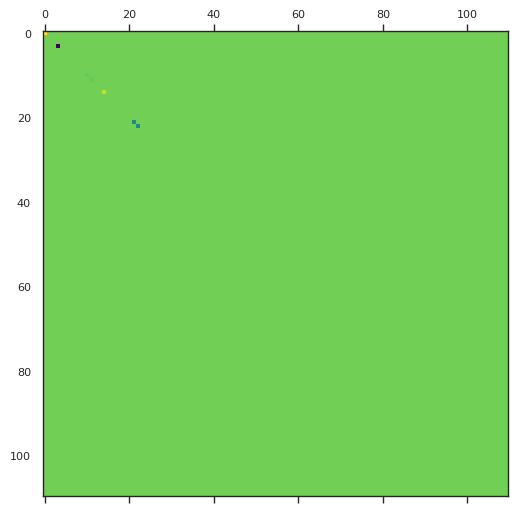

In [19]:
plt.matshow(tensor_lamda.real.detach(), cmap="viridis")

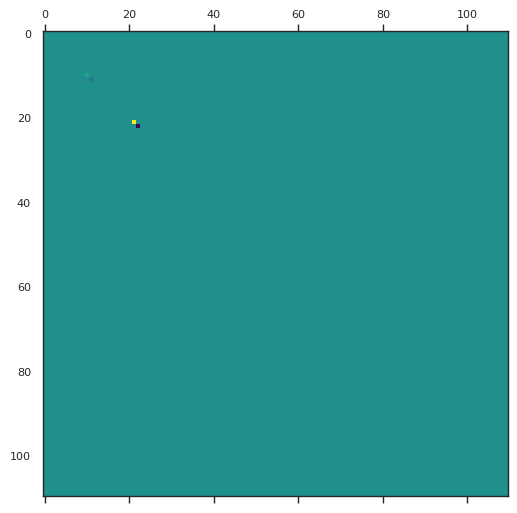

In [20]:
plt.matshow(tensor_lamda.imag.detach(), cmap="viridis")

In [21]:
torch.diag(tensor_lamda)

tensor([ 4.3526e-01-5.7978e-08j,  2.0799e-04+2.7604e-04j,
         2.7543e-04-2.9449e-04j, -1.6090e+00-3.6289e-07j,
        -3.8219e-05-2.2478e-04j, -9.5049e-05+1.3706e-04j,
         6.9371e-05+2.0506e-04j,  3.3990e-05+7.8800e-05j,
         3.2331e-05-8.5139e-05j,  1.1268e-04-1.0978e-04j,
        -5.2381e-02+7.5425e-02j, -5.2379e-02-7.5421e-02j,
        -5.7056e-05-1.6855e-04j,  5.8768e-06+3.2566e-05j,
         2.4398e-01-4.1730e-06j, -2.2301e-05-2.6495e-05j,
         3.6989e-04+4.0659e-05j,  3.3448e-04-1.1872e-04j,
         1.3999e-04-7.9224e-05j, -2.3480e-04-6.3900e-05j,
         2.1816e-04+1.4963e-04j, -6.3406e-01+4.5967e-01j,
        -6.3409e-01-4.5969e-01j,  6.3774e-05+1.3962e-04j,
         3.5196e-05+2.9867e-05j,  7.2102e-05-1.2038e-04j,
         6.8528e-06+2.2059e-05j, -4.9651e-05-6.6091e-07j,
         1.6961e-05-3.8699e-05j, -6.8907e-05-5.1741e-05j,
        -7.3332e-05-6.9656e-05j,  1.2586e-04+1.9210e-05j,
        -9.3901e-06-3.1800e-05j, -1.5337e-04-5.6465e-05j,
        -2.592